# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [12]:

import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [31]:
# ============================================================
# 1. CONFIGURAÇÕES
# ============================================================

ARQUIVO = "../data/raw/DataSetKaggle.csv"

# Valores de K que serão testados
VALORES_K = [3, 5, 7, 9, 11, 15, 20, 25, 30, 40, 50]

METRICAS_DISTANCIA = [
    "euclidean",
    "manhattan",
    "chebyshev"
]

# Pasta onde os resultados serão salvos
PASTA_RESULTADOS = "../results/metrics"

In [14]:
# ==========================================
# 2. CARREGAMENTO DO DATASET
# ==========================================

print("Carregando DATASET...")

df = pd.read_csv(ARQUIVO)

print(f"Quantidade de REGISTROS: {len(df)}")
print(f"Quantidade de colunas: {len(df.columns)}")

df.head()

Carregando DATASET...
Quantidade de REGISTROS: 184152
Quantidade de colunas: 38


,idLobbyGame,idPlayer,idRoom,qtKill,qtAssist,qtDeath,qtHs,qtBombeDefuse,qtBombePlant,qtTk,...,qtFlashAssist,qtHitHeadshot,qtHitChest,qtHitStomach,qtHitLeftAtm,qtHitRightArm,qtHitLeftLeg,qtHitRightLeg,flWinner,dtCreatedAt
0,1,1,1,5,1,16,2,0,0,0.0,...,0.0,3.0,13.0,4.0,2.0,2.0,1.0,0.0,0,2022-01-21 19:45:44
1,2,1,2,24,3,18,6,0,4,0.0,...,0.0,7.0,26.0,14.0,2.0,1.0,1.0,3.0,1,2022-02-04 02:09:47
2,3,2,3,6,4,23,2,0,1,0.0,...,0.0,3.0,15.0,8.0,1.0,2.0,0.0,2.0,0,2021-09-18 18:07:43
3,3,391,27508,10,5,20,4,1,0,0.0,...,0.0,6.0,27.0,10.0,1.0,7.0,6.0,6.0,1,2021-09-18 18:07:43
4,4,2,4,8,4,26,6,0,2,0.0,...,2.0,8.0,19.0,12.0,2.0,3.0,2.0,5.0,0,2021-09-27 00:17:45


In [15]:
# ==========================================
# 3. PREPARAÇÃO DA DATA
# ==========================================

# Converte a coluna de data para o formato datetime
df["dtCreatedAt"] = pd.to_datetime(
    df["dtCreatedAt"],
    errors="coerce"
)

# Remove registros sem data
df = df.dropna(subset=["dtCreatedAt"])


In [16]:
# ============================================================
# 4. ORDENAR CRONOLOGICAMENTE
# ============================================================

# IMPORTANTE:
# Ordenamos por jogador e depois pela data.
#
# Assim, quando criarmos as médias históricas,
# cada partida só poderá utilizar informações
# de partidas anteriores daquele jogador.

df = df.sort_values(
    ["idPlayer", "dtCreatedAt"]
).reset_index(drop=True)

In [17]:
# ============================================================
# 5. CRIAR HISTÓRICO DO JOGADOR
# ============================================================

grupo_jogador = df.groupby("idPlayer")


# ------------------------------------------------------------
# Média de kills anteriores
# ------------------------------------------------------------

df["media_kills"] = (
    grupo_jogador["qtKill"]
    .transform(
        lambda x: x.shift().expanding().mean()
    )
)


# ------------------------------------------------------------
# Média de assists anteriores
# ------------------------------------------------------------

df["media_assist"] = (
    grupo_jogador["qtAssist"]
    .transform(
        lambda x: x.shift().expanding().mean()
    )
)


# ------------------------------------------------------------
# Média de deaths anteriores
# ------------------------------------------------------------

df["media_death"] = (
    grupo_jogador["qtDeath"]
    .transform(
        lambda x: x.shift().expanding().mean()
    )
)


# ------------------------------------------------------------
# Média de rounds anteriores
# ------------------------------------------------------------

df["media_rounds"] = (
    grupo_jogador["qtRoundsPlayed"]
    .transform(
        lambda x: x.shift().expanding().mean()
    )
)

In [18]:
# ============================================================
# 6. CRIAR KILLS POR ROUND
# ============================================================

# Primeiro calculamos o total de kills anteriores
df["kills_anteriores"] = (
    grupo_jogador["qtKill"]
    .transform(
        lambda x: x.shift().cumsum()
    )
)

# Depois calculamos o total de rounds anteriores
df["rounds_anteriores"] = (
    grupo_jogador["qtRoundsPlayed"]
    .transform(
        lambda x: x.shift().cumsum()
    )
)

# Evita divisão por zero
df["kill_por_round"] = (
    df["kills_anteriores"] /
    df["rounds_anteriores"].replace(0, pd.NA)
)


In [19]:
# ============================================================
# 7. REMOVER REGISTROS SEM HISTÓRICO
# ============================================================

# A primeira partida de cada jogador não possui
# partidas anteriores para calcular as médias.
#
# Portanto, esses registros não podem ser utilizados
# para esse modelo.

colunas_historicas = [
    "media_kills",
    "media_assist",
    "media_death",
    "media_rounds",
    "kill_por_round"
]

df = df.dropna(
    subset=colunas_historicas
).reset_index(drop=True)


In [20]:
# ============================================================
# 8. DEFINIR FEATURES E TARGET
# ============================================================

# Variáveis utilizadas para prever a quantidade
# de kills da próxima partida.

features_numericas = [
    "media_kills",
    "media_assist",
    "media_death",
    "media_rounds",
    "kill_por_round",
    "vlLevel"
]

features_categoricas = [
    "descMapName"
]

# Variável que queremos prever
target = "qtKill"


X = df[
    features_numericas + features_categoricas
]

y = df[target]

In [21]:
# ============================================================
# 9. DIVISÃO 70% / 30%
# ============================================================

# ATENÇÃO:
# Como estamos trabalhando com histórico temporal,
# não vamos embaralhar os dados.
#
# Os primeiros 70% serão utilizados para aprendizado
# e os últimos 30% para teste.

quantidade_treino = int(len(df) * 0.70)

X_treino = X.iloc[:quantidade_treino]
X_teste = X.iloc[quantidade_treino:]

y_treino = y.iloc[:quantidade_treino]
y_teste = y.iloc[quantidade_treino:]


print()
print("Divisão dos dados:")
print(f"Treino: {len(X_treino)} registros")
print(f"Teste:  {len(X_teste)} registros")




Divisão dos dados:
Treino: 127178 registros
Teste:  54505 registros


In [22]:
# ============================================================
# 10. PRÉ-PROCESSAMENTO
# ============================================================

# KNN utiliza distância para encontrar os vizinhos.
#
# Por isso precisamos normalizar as variáveis numéricas.
#
# Também precisamos transformar o mapa em números
# utilizando OneHotEncoder.

preprocessador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            features_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            features_categoricas
        )
    ]
)


In [23]:
# ============================================================
# 11. TESTAR DIFERENTES VALORES DE K E DISTÂNCIAS
# ============================================================

resultados = []

print()
print("Testando valores de K e métricas de distância...")
print("================================================")


for k in VALORES_K:

    for metrica in METRICAS_DISTANCIA:

        # ----------------------------------------------------
        # Criar modelo KNN
        # ----------------------------------------------------

        modelo = Pipeline(
            steps=[
                (
                    "preprocessamento",
                    preprocessador
                ),
                (
                    "knn",
                    KNeighborsRegressor(
                        n_neighbors=k,
                        metric=metrica
                    )
                )
            ]
        )


        # ----------------------------------------------------
        # Treinar
        # ----------------------------------------------------

        modelo.fit(
            X_treino,
            y_treino
        )


        # ----------------------------------------------------
        # Fazer previsões
        # ----------------------------------------------------

        previsoes = modelo.predict(
            X_teste
        )


        # ----------------------------------------------------
        # Calcular métricas
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_teste,
            previsoes
        )

        rmse = mean_squared_error(
            y_teste,
            previsoes
        ) ** 0.5

        r2 = r2_score(
            y_teste,
            previsoes
        )


        # ----------------------------------------------------
        # Mostrar resultado
        # ----------------------------------------------------

        print(
            f"K = {k} | "
            f"Distância = {metrica} | "
            f"MAE = {mae:.4f} | "
            f"RMSE = {rmse:.4f} | "
            f"R² = {r2:.4f}"
        )


        # ----------------------------------------------------
        # Guardar resultado
        # ----------------------------------------------------

        resultados.append({
            "k": k,
            "distancia": metrica,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


Testando valores de K e métricas de distância...
K = 3 | Distância = euclidean | MAE = 6.2629 | RMSE = 8.0045 | R² = -0.1892
K = 3 | Distância = manhattan | MAE = 6.2405 | RMSE = 7.9823 | R² = -0.1826
K = 3 | Distância = chebyshev | MAE = 6.2945 | RMSE = 8.0295 | R² = -0.1967
K = 5 | Distância = euclidean | MAE = 5.9320 | RMSE = 7.5903 | R² = -0.0693
K = 5 | Distância = manhattan | MAE = 5.9071 | RMSE = 7.5751 | R² = -0.0650
K = 5 | Distância = chebyshev | MAE = 5.9461 | RMSE = 7.6054 | R² = -0.0736
K = 7 | Distância = euclidean | MAE = 5.7706 | RMSE = 7.4051 | R² = -0.0178
K = 7 | Distância = manhattan | MAE = 5.7669 | RMSE = 7.3951 | R² = -0.0150
K = 7 | Distância = chebyshev | MAE = 5.7811 | RMSE = 7.4086 | R² = -0.0188
K = 9 | Distância = euclidean | MAE = 5.6816 | RMSE = 7.2945 | R² = 0.0124
K = 9 | Distância = manhattan | MAE = 5.6775 | RMSE = 7.2875 | R² = 0.0143
K = 9 | Distância = chebyshev | MAE = 5.6925 | RMSE = 7.3021 | R² = 0.0103
K = 11 | Distância = euclidean | MAE = 5.

In [47]:
# ============================================================
# 12. TRANSFORMAR RESULTADOS EM DATAFRAME
# ============================================================

resultados_df = pd.DataFrame(
    resultados
)

In [36]:
# ============================================================
# 12. IDENTIFICAR A MELHOR CONFIGURAÇÃO
# ============================================================

# Vamos escolher a configuração com menor MAE.

melhor_resultado = resultados_df.loc[
    resultados_df["MAE"].idxmin()
]


melhor_k = int(
    melhor_resultado["k"]
)

melhor_distancia = (
    melhor_resultado["distancia"]
)


print()
print("MELHOR CONFIGURAÇÃO")
print("==============================")

print(
    f"K: {melhor_k}"
)

print(
    f"Distância: {melhor_distancia}"
)

print(
    f"MAE: {melhor_resultado['MAE']:.4f}"
)

print(
    f"RMSE: {melhor_resultado['RMSE']:.4f}"
)

print(
    f"R²: {melhor_resultado['R2']:.4f}"
)


MELHOR CONFIGURAÇÃO
K: 50
Distância: manhattan
MAE: 5.4045
RMSE: 6.9661
R²: 0.0993


In [48]:
# ============================================================
# 14. SALVAR RESULTADOS
# ============================================================

os.makedirs(
    PASTA_RESULTADOS,
    exist_ok=True
)

arquivo_resultados = (
    f"{PASTA_RESULTADOS}/knn_resultados.csv"
)

resultados_df.to_csv(
    arquivo_resultados,
    index=False
)


print()
print(
    f"Resultados salvos em: "
    f"{arquivo_resultados}"
)


Resultados salvos em: ../results/metrics/knn_resultados.csv


In [49]:
# ============================================================
# 15. TREINAR O MELHOR K NOVAMENTE
# ============================================================

# Vamos considerar a melhor configuração aquela que apresentou
# o menor MAE.

melhor_resultado = resultados_df.loc[
    resultados_df["MAE"].idxmin()
]

melhor_k = int(
    melhor_resultado["k"]
)

melhor_distancia = (
    melhor_resultado["distancia"]
)


print()
print(f"Melhor K encontrado: {melhor_k}")
print(f"Melhor distância encontrada: {melhor_distancia}")


# Criar o modelo utilizando o melhor K
# e a melhor métrica de distância
modelo_final = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "knn",
            KNeighborsRegressor(
                n_neighbors=melhor_k,
                metric=melhor_distancia
            )
        )
    ]
)


# Treinar novamente
modelo_final.fit(
    X_treino,
    y_treino
)


# Fazer as previsões no conjunto de teste
previsoes_finais = modelo_final.predict(
    X_teste
)


# Calcular as métricas do modelo final
mae_final = mean_absolute_error(
    y_teste,
    previsoes_finais
)

rmse_final = mean_squared_error(
    y_teste,
    previsoes_finais
) ** 0.5

r2_final = r2_score(
    y_teste,
    previsoes_finais
)


# Mostrar os resultados finais
print()
print("RESULTADOS DO MODELO FINAL")
print("==============================")
print(f"MAE:  {mae_final:.4f}")
print(f"RMSE: {rmse_final:.4f}")
print(f"R²:   {r2_final:.4f}")


Melhor K encontrado: 50
Melhor distância encontrada: manhattan

RESULTADOS DO MODELO FINAL
MAE:  5.4045
RMSE: 6.9661
R²:   0.0993


In [50]:
# ============================================================
# 16. CRIAR ARQUIVO COM REAL VS PREVISTO
# ============================================================

previsoes_df = pd.DataFrame({
    "qtKill_real": y_teste.values,
    "qtKill_previsto": previsoes_finais
})


# Calcular o erro de cada previsão
previsoes_df["erro"] = (
    previsoes_df["qtKill_real"]
    - previsoes_df["qtKill_previsto"]
)


# Erro absoluto
previsoes_df["erro_absoluto"] = (
    previsoes_df["erro"].abs()
)


# Salvar
arquivo_previsoes = (
    f"{PASTA_RESULTADOS}/knn_previsoes.csv"
)

previsoes_df.to_csv(
    arquivo_previsoes,
    index=False
)


print(
    f"Previsões salvas em: "
    f"{arquivo_previsoes}"
)

Previsões salvas em: ../results/metrics/knn_previsoes.csv


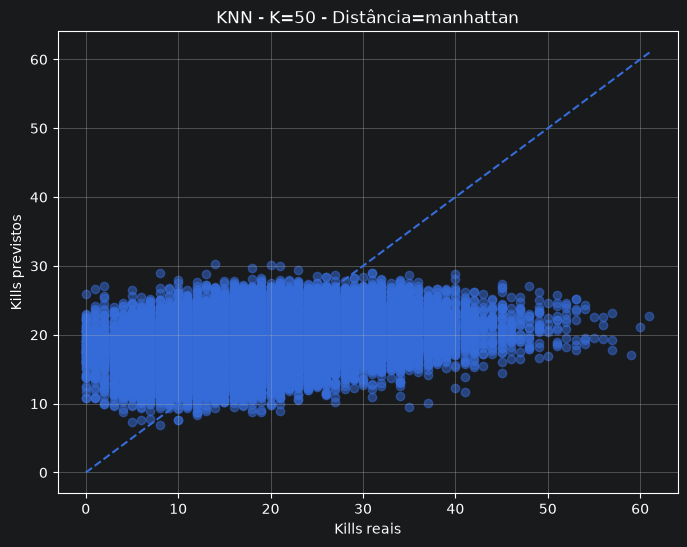

In [40]:
# ============================================================
# 17. GRÁFICO - KILLS REAIS X KILLS PREVISTOS
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))


# Pontos das previsões
plt.scatter(
    y_teste,
    previsoes_finais,
    alpha=0.5
)


# Linha de previsão perfeita
limite = max(
    y_teste.max(),
    previsoes_finais.max()
)

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--"
)


# Configurações do gráfico
plt.xlabel("Kills reais")
plt.ylabel("Kills previstos")

plt.title(
    f"KNN - K={melhor_k} - Distância={melhor_distancia}"
)

plt.grid(True)

plt.show()

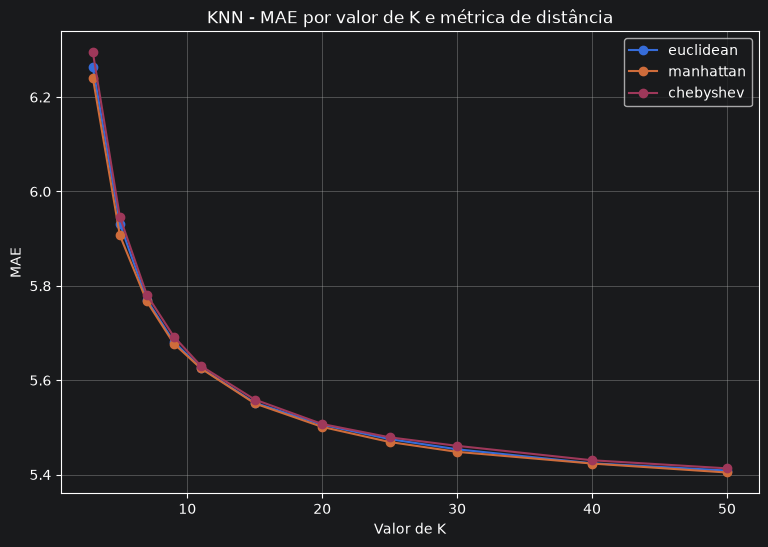

In [41]:
# ============================================================
# 17. GRÁFICO - K X MAE
# ============================================================

plt.figure(figsize=(9, 6))


for metrica in METRICAS_DISTANCIA:

    dados_metrica = resultados_df[
        resultados_df["distancia"] == metrica
    ]

    plt.plot(
        dados_metrica["k"],
        dados_metrica["MAE"],
        marker="o",
        label=metrica
    )


# Configurações do gráfico
plt.xlabel("Valor de K")
plt.ylabel("MAE")

plt.title(
    "KNN - MAE por valor de K e métrica de distância"
)

plt.legend()

plt.grid(True)

plt.show()